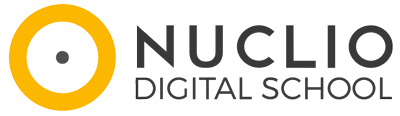

# Intro al problema


## El proyecto

**Introducción al Problema**

Una empresa de e-commerce necesita un modelo para categorizar las reviews de los clientes en twitter y así entender su nivel de satisfacción y proponer mejoras. Como departamento de datos, nos llega una petición de que implementaremos un modelo de análisis de sentimientos. En lugar de crear uno desde cero, evaluaremos modelos preentrenados disponibles en Hugging Face.

**Objetivo**

El objetivo es buscar modelos preentrenados en Hugging Face que puedan analizar sentimientos. Necesitamos evaluar su desempeño para nuestra empresa, y para ello disponemos de un conjunto de datos etiquetados (tweets con reviews y su sentimiento asociado, etiquetado por una persona).  

**Tareas**

1. Buscar Modelos en Hugging Face: Identificar modelos de análisis de sentimientos en Hugging Face Hub que se adapten a nuestras necesidades.
2.	Evaluación del Modelo: Probar los modelos seleccionados utilizando nuestras revisiones etiquetadas (positivas y negativas) para validar su precisión y rendimiento.
3.	Validación del Modelo: Comparar los resultados de los modelos con nuestras etiquetas para asegurarnos de que el modelo seleccionado funcione correctamente.


## ¿Qué es sentiment analysis?

El análisis de sentimiento (sentiment analysis) es un subcampo del NLP, que tiene como objetivo identificar el tono emocional de un texto. Esto permite a las organizaciones identificar un sentimiento positivo, neutral o negativo con respecto a la marca, productos, servicios o ideas. La idea detrás del análisis de sentimientos es extraer información de grandes cantidades de datos de texto no estructurados y comprender el sentimiento general de una población hacia un tema particular.

<div style="text-align: center;">
<img src="https://www.kdnuggets.com/wp-content/uploads/mayo_sent_analysis_fastapi_transformers-0.jpg" alt="Sentiment Analysis" width="400"/>
</div>

## Usos del sentiment analysis

- **Mejorar la experiencia del cliente:** se puede utilizar para comprender las opiniones y comentarios de los clientes sobre productos y servicios, lo que permite a las empresas mejorar la experiencia del cliente.

- **Investigación de mercado:** se puede utilizar para monitorear el sentimiento de un público hacia un tema o marca en particular, proporcionando información valiosa sobre las tendencias del mercado y las preferencias de los clientes.

- **Mejorar el diseño de productos:** se puede utilizar para comprender las preferencias y opiniones de los clientes sobre las características de los productos, permitiendo a las empresas diseñar productos que se adapten mejor a las necesidades de los clientes.

- **Mejorar la monitorización de redes sociales:** se puede utilizar para monitorizar las conversaciones en las redes sociales y comprender el tono y el sentimiento detrás de ellas.


## Técnicas para sentiment analysis (nice to know)
De manera tradicional, el análisis de sentimientos se realizaba utilizando técnicas de ML como Support Vecotr Machines (SVM) y los Clasificadores Naive Bayes. Sin embargo, estas técnicas presentaban varias limitaciones, como la incapacidad para capturar el contexto y la necesidad de un gran conjunto de datos anotados para el entrenamiento.

Los transformers han sido un avance revolucionario en el procesamiento del lenguaje natural (NLP) que ha transformado el campo del análisis de sentimientos (entre muchos otros). Son un tipo de modelos de deep learning introducidos en 2017 por Vaswani et al. en el artículo “Attention is All You Need”. Estos modelos se basan en la arquitectura Transformer y utilizan mecanismos de self-attention para procesar la secuencia de entrada, permitiendo al modelo capturar el contexto y las dependencias entre palabras.

# Parte 1. Testing sentiment analysis on Hugging Face


## Pipelines in Hugging Face

El comando `pip install transformers` se utiliza para instalar el paquete transformers, que proporciona acceso a modelos basados en Transformers para tareas de procesamiento del lenguaje natural (NLP), incluido el análisis de sentimientos.
Una vez que el paquete transformers está instalado, podemos importar y utilizar los modelos en nuestros proyectos.

In [5]:
# install transformers
!pip install transformers

   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   -------- ------------------------------- 2.4/11.6 MB 14.7 MB/s eta 0:00:01
   -------------------- ------------------- 6.0/11.6 MB 15.0 MB/s eta 0:00:01
   --------------------------------- ------ 9.7/11.6 MB 16.0 MB/s eta 0:00:01
   ---------------------------------------- 11.6/11.6 MB 15.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/561.5 kB ? eta -:--:--
   --------------------------------------- 561.5/561.5 kB 12.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 14.7 MB/s eta 0:00:00


In [ ]:
import subprocess

#Comprobamos que la librería se ha instalado correctamente
module = 'transformers' 
result = subprocess.run(['pip', 'list'], capture_output=True, text=True)
if module in result.stdout:
    print("Transformers está instalado")
    # Mostrar la línea específica
    for line in result.stdout.split('\n'):
        if module in line.lower():
            print(line)
else:
    print("Transformers no encontrado")

In [8]:
!pip install torch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/241.3 MB ? eta -:--:--
   ---------------------------------------- 2.1/241.3 MB 13.7 MB/s eta 0:00:18
    --------------------------------------- 5.5/241.3 MB 14.8 MB/s eta 0:00:16
   - -------------------------------------- 9.4/241.3 MB 15.9 MB/s eta 0:00:15
   -- ------------------------------------- 12.8/241.3 MB 16.2 MB/s eta 0:00:15
   -- ------------------------------------- 16.5/241.3 MB 16.1 MB/s eta 0:00:14
   --- ------------------------------------ 19.9/241.3 MB 16.2 MB/s eta 0:00:14
   --- ------------------------------------ 23.9/241.3 MB 16.5 MB/s eta 0:00:14
   ---- ----------------------------------- 27.3/241.3 MB 16.4 MB/s eta 0:00:14
   ----- ---------------------------------- 31.2/241.3 MB 16.6 MB/s eta 0:00:13
   ----- ---------------------------------- 34.9/241.3 MB 16.8 MB/s eta 0:00:13
   ----

**¿Qué es un pipeline en Hugging Face?**

Un pipeline en Hugging Face es una API de alto nivel que permite realizar tareas de procesamiento del lenguaje natural (NLP) utilizando modelos pre-entrenados. Los pipelines simplifican el uso de estos modelos al proporcionar interfaces fáciles de usar para varias tareas comunes de NLP, como análisis de sentimientos, clasificación de texto, generación de texto, traducción, reconocimiento de entidades, entre otras.

Los pipelines son útiles porque abstraen muchos detalles técnicos, permitiendo a los usuarios aplicar modelos avanzados de NLP con unas pocas líneas de código.

In [1]:
# pipeline es una función de Hugging Face que permite crear fácilmente pipelines para diferentes tareas de NLP 
# utilizando modelos pre-entrenados.
from transformers import pipeline

# Al llamar a pipeline con el argumento 'sentiment-analysis', se configura el pipeline para realizar análisis
# de sentimientos utilizando un modelo pre-entrenado.
# El modelo por defecto que se utiliza es uno que ha sido entrenado para clasificar el sentimiento de un texto
# como positivo o negativo.
classification = pipeline('sentiment-analysis')

c:\Users\cde\AppData\Local\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


Device set to use cpu


Con estas dos líneas de código, hemos creado un pipeline de análisis de sentimientos que se puede utilizar para clasificar el sentimiento de un texto dado como positivo, negativo o neutral.

Con el código classification = pipeline('sentiment-analysis'), se está utilizando el modelo por defecto de Hugging Face para la tarea de análisis de sentimientos. El modelo por defecto para esta tarea es generalmente distilbert-base-uncased-finetuned-sst-2-english.

Si hubiéramos preferido otro modelo, podríamos haberlo especificado asÏ:
```python
# Crear pipeline para análisis de sentimientos usando un modelo específico
classification = pipeline('sentiment-analysis', model='nlptown/bert-base-multilingual-uncased-sentiment')


In [2]:
# Print información del modelo utilizado
print(classification.model.name_or_path)

distilbert/distilbert-base-uncased-finetuned-sst-2-english


Ahora podemos utilizar el objeto `classification` para realizar análisis de sentimientos en cualquier texto llamando a su método `predict` y pasando el texto como argumento.

In [4]:
# segunda prueba en una review de una película
classification("The movie was boring as f**")


[{'label': 'NEGATIVE', 'score': 0.9998102784156799}]

In [6]:
# tercera prueba en una review de una película
classification("Liked it, disliked it, I am not sure")


[{'label': 'NEGATIVE', 'score': 0.550291121006012}]

Probemos con reviews más complejas...

In [7]:
classification('''Although the movie had its flaws and some scenes were slow-paced,
                I still found myself captivated by the strong performances and unique storyline.
                The cinematography was stunning and added another level of depth to the film. Overall,
                I would still recommend it for those looking for a thought-provoking movie experience.''')

[{'label': 'POSITIVE', 'score': 0.999847412109375}]

In [8]:
classification('''At first, I was intrigued by the premise and was excited to see where the story would go.
                However, as the movie progressed, I became disappointed by the lackluster execution and
                underdeveloped characters. Despite a few moments of promise, the movie ultimately fell
                flat for me and failed to deliver on its potential. Not recommended.''')

[{'label': 'NEGATIVE', 'score': 0.9997879862785339}]

Si queremos, podemos pasar varias reviews como una lista

In [9]:
classification(["The movie was boring as f**",
                "Liked it, disliked it, I am not sure"])

[{'label': 'NEGATIVE', 'score': 0.9998102784156799},
 {'label': 'NEGATIVE', 'score': 0.550291121006012}]

# Parte 2. Sentiment analaysis project

## 1) Import libraries

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')



## 2) Paths and directories

In [6]:
path_input_dataset = './twitter_training.csv'

## 3) Load dataset

In [7]:
twitter_data = pd.read_csv(path_input_dataset)

print(f'Shape of the input dataframe: {twitter_data.shape}')
display(twitter_data.head())

Shape of the input dataframe: (74681, 4)


,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


## 4) Quick checks & **transformations**

### Nombres de columnas

In [8]:
# Las columnas parecen no tener nombre, las renombramos
# Renombrar las columnas
twitter_data.columns = ['tweet_id', 'topic', 'sentiment', 'tweet_content']

# Mostrar las primeras filas con los nuevos nombres de columnas
display(twitter_data.head())

,tweet_id,topic,sentiment,tweet_content
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


### Missing values

In [9]:
# Verificar valores faltantes
missing_values = twitter_data.isnull().sum()
print(f"Valores faltantes:\n{missing_values}")

# Mostrar un par de ejemplos con missing
display(twitter_data[twitter_data.tweet_content.isnull()].head())

# Eliminar filas con Tweet_Content faltante
twitter_data = twitter_data.dropna(subset=['tweet_content'])
print(f'Shape of the dataframe after removing nas: {twitter_data.shape}')

Valores faltantes:
tweet_id           0
topic              0
sentiment          0
tweet_content    686
dtype: int64


,tweet_id,topic,sentiment,tweet_content
60,2411,Borderlands,Neutral,NaN
552,2496,Borderlands,Neutral,NaN
588,2503,Borderlands,Neutral,NaN
744,2532,Borderlands,Positive,NaN
1104,2595,Borderlands,Positive,NaN


Shape of the dataframe after removing nas: (73995, 4)


### Duplicados

In [26]:
# Verificar si hay duplicados
duplicated_rows = twitter_data.duplicated().sum()
print(f"Filas duplicadas: {duplicated_rows}")

# Eliminar filas duplicadas
twitter_data_clean = twitter_data.drop_duplicates()

print(f'Shape of the dataframe after removing duplicates: {twitter_data_clean.shape}')


Filas duplicadas: 2340
Shape of the dataframe after removing duplicates: (71655, 4)


### Describe

In [11]:
# Resumir el DataFrame
summary_stats_numeric = twitter_data_clean.describe(include='number')
print(f"Estadísticas de variables numéricas:\n{summary_stats_numeric}")

# Resumir el DataFrame
summary_stats_notnumber = twitter_data_clean.describe(exclude='number')
print(f"\nEstadísticas de variables caetegóricas:\n{summary_stats_notnumber}")

Estadísticas de variables numéricas:
           tweet_id
count  71655.000000
mean    6436.493559
std     3742.287116
min        1.000000
25%     3199.000000
50%     6433.000000
75%     9604.000000
max    13200.000000

Estadísticas de variables caetegóricas:
                       topic sentiment tweet_content
count                  71655     71655         71655
unique                    32         4         69490
top     TomClancysRainbowSix  Negative              
freq                    2328     21698           172


## 5) Analysis

In [12]:
# Función para mostrar recuentos y porcentajes
def value_counts_with_percentages(series):
    counts = series.value_counts()
    percentages = series.value_counts(normalize=True) * 100
    return pd.DataFrame({'Counts': counts, 'Percentages': percentages})

### Distribución de sentimientos

Distribución de Sentimientos:
            Counts  Percentages
sentiment                      
Negative     21698    30.281209
Positive     19712    27.509595
Neutral      17708    24.712860
Irrelevant   12537    17.496337


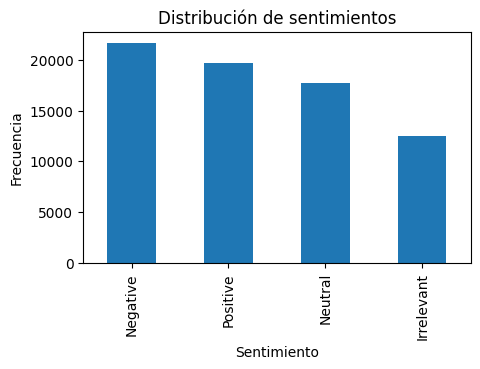

In [13]:
# Distribución de Sentimientos
sentiment_distribution = value_counts_with_percentages(twitter_data_clean['sentiment'])
print(f"Distribución de Sentimientos:\n{sentiment_distribution}")

# Plot de la distribución de sentimientos
fig, ax = plt.subplots(figsize=(5, 3))
sentiment_distribution['Counts'].plot(kind='bar')
plt.title('Distribución de sentimientos')
plt.xlabel('Sentimiento')
plt.ylabel('Frecuencia')
plt.show()


### Distribución de números de tweets por juego

Número de tweets por topic:
                                   Counts  Percentages
topic                                                 
TomClancysRainbowSix                 2328     3.248901
Verizon                              2319     3.236341
MaddenNFL                            2315     3.230758
CallOfDuty                           2314     3.229363
Microsoft                            2304     3.215407
WorldOfCraft                         2300     3.209825
NBA2K                                2299     3.208429
LeagueOfLegends                      2296     3.204243
TomClancysGhostRecon                 2291     3.197265
Facebook                             2289     3.194474
ApexLegends                          2278     3.179122
johnson&johnson                      2257     3.149815
Battlefield                          2255     3.147024
Amazon                               2249     3.138650
CallOfDutyBlackopsColdWar            2242     3.128881
FIFA                                 

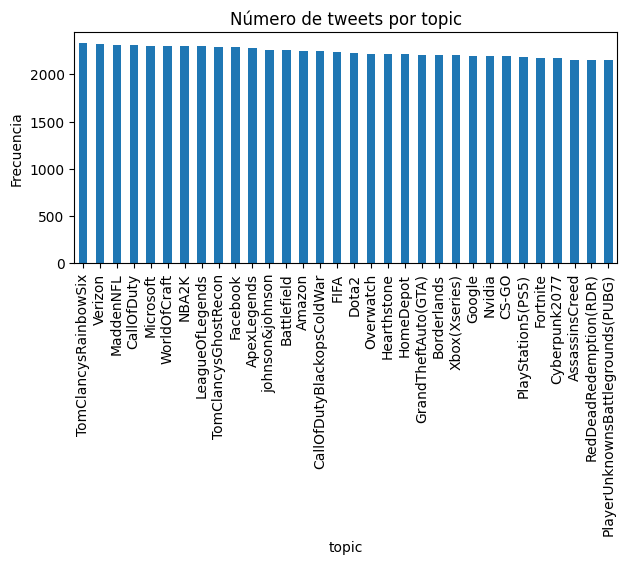

In [14]:
# Número de tweets por juego
tweets_per_topic = value_counts_with_percentages(twitter_data_clean['topic'])
print(f"Número de tweets por topic:\n{tweets_per_topic}")

# Plot del número de tweets por juego
fig, ax = plt.subplots(figsize=(5, 2))
tweets_per_topic['Counts'].plot(kind='bar', figsize=(7, 3))
plt.title('Número de tweets por topic')
plt.xlabel('topic')
plt.ylabel('Frecuencia')
plt.show()

### Distribución de sentimientos por topic


Distribución de sentimientos por tópico:
sentiment                          Irrelevant  Negative  Neutral  Positive
topic                                                                     
Amazon                                    185       565     1197       302
ApexLegends                               185       574      913       606
AssassinsCreed                            256       365      153      1382
Battlefield                               907       445      342       561
Borderlands                               238       415      581       971
CS-GO                                     620       335      523       717
CallOfDuty                                660       861      367       426
CallOfDutyBlackopsColdWar                 545       540      340       817
Cyberpunk2077                             457       360      456       902
Dota2                                     401       705      579       540
FIFA                                      538      1127    

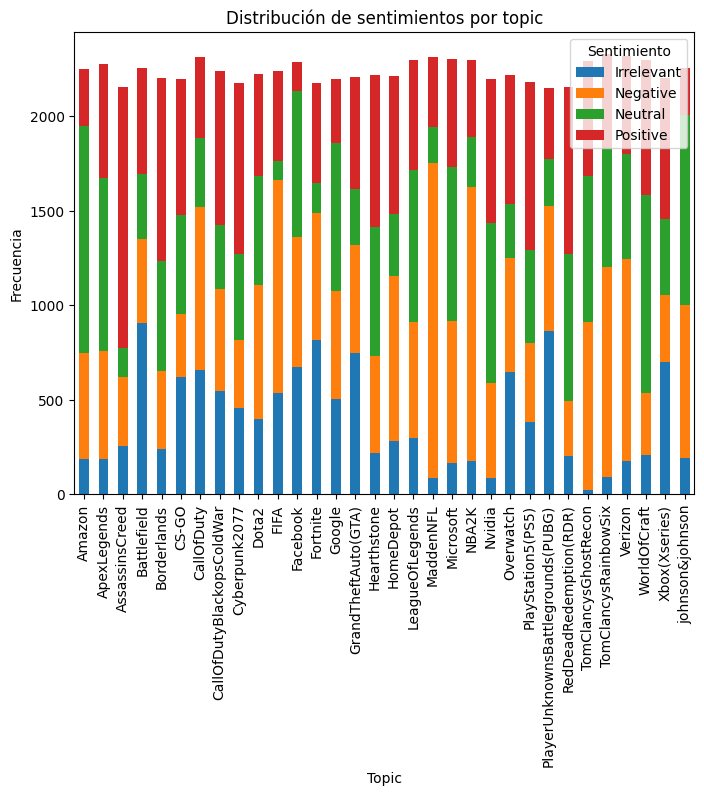

In [15]:
# Distribución de sentimientos por topic
sentiment_by_topic = twitter_data_clean.groupby(['topic', 'sentiment']).size().unstack().fillna(0)
sentiment_by_topic_percentage = sentiment_by_topic.div(sentiment_by_topic.sum(axis=1), axis=0) * 100
print(f"Distribución de sentimientos por tópico:\n{sentiment_by_topic}")
print(f"Porcentajes de sentimientos por tópico:\n{sentiment_by_topic_percentage}")

# Plot de la distribución de sentimientos por tópico
sentiment_by_topic.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Distribución de sentimientos por topic')
plt.xlabel('Topic')
plt.ylabel('Frecuencia')
plt.legend(title='Sentimiento')
plt.show()

## 6) Sentiment analysis
El modelo que estamos usando de Hugging Face está entrenado para predecir únicamente positivo o negativo. Vamos a considerar solamente estos dos tipos de reviews


### Prepare input

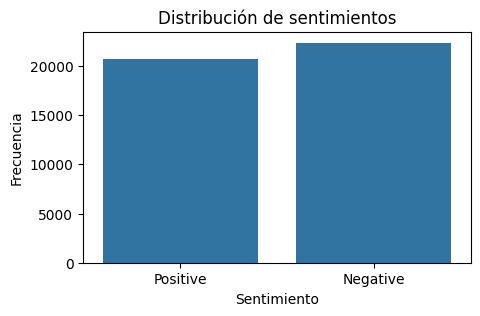

In [16]:
# Filtramos sentimientos distintos de positivo o negativo
twitter_data_model = twitter_data[(twitter_data.sentiment == 'Positive') | (twitter_data.sentiment == 'Negative')]

# Plot de la nueva distribución de sentimientos
fig, ax = plt.subplots(figsize=(5, 3))
sns.countplot(x='sentiment', data=twitter_data_model)
plt.title('Distribución de sentimientos')
plt.xlabel('Sentimiento')
plt.ylabel('Frecuencia')
plt.show()

Necesitamos extraer los tweets (columna tweet_content) a una lista que pasar al modelo

In [17]:
input_tweets = twitter_data_model['tweet_content'].to_list()


### Predictions

In [18]:
# Optional (run with only x records if gpu not available)
n_records = 100
predictions_tweets = classification(input_tweets[:n_records])


In [19]:
# Print un par de predicciones
predictions_tweets[:10]


[{'label': 'POSITIVE', 'score': 0.9932870268821716},
 {'label': 'POSITIVE', 'score': 0.9783737659454346},
 {'label': 'NEGATIVE', 'score': 0.9768757820129395},
 {'label': 'POSITIVE', 'score': 0.7018877267837524},
 {'label': 'NEGATIVE', 'score': 0.9805620312690735},
 {'label': 'NEGATIVE', 'score': 0.7845353484153748},
 {'label': 'NEGATIVE', 'score': 0.9357828497886658},
 {'label': 'POSITIVE', 'score': 0.9987744688987732},
 {'label': 'NEGATIVE', 'score': 0.937289834022522},
 {'label': 'NEGATIVE', 'score': 0.9648420810699463}]

Las predicciones tienen un formato de lista de diccionarios con etiqueta (positiva o negativa) y la probabilidad asociada (ojo, probabilidad de positivo o negativo según el caso).

Para evaluar la performance del modelo sobre nuestros datos, vamos a transformar esas predicciones a 1 (positivo) o 0 (negativo). Haremos lo mismo para la etiqueta real en los datos de entrada.


In [20]:
preds_label = [1 if x['label'].startswith('P') else 0 for x in predictions_tweets]
preds_label[:5]


[1, 1, 0, 1, 0]

Podemos ajustar las probabilidades, para que todas reflejen probabilidad de positivo.  

In [21]:
preds_prob = [x['score'] if x['label'].startswith('P') else 1 - x['score'] for x in predictions_tweets ]
preds_prob[:5]


[0.9932870268821716,
 0.9783737659454346,
 0.023124217987060547,
 0.7018877267837524,
 0.019437968730926514]

In [22]:
# Crear nueva columna binaria 1 (positivo) o 0 (negativo) en los datos de entrada
target_map = { 'Positive': 1, 'Negative': 0}
twitter_data_model['target'] = twitter_data_model['sentiment'].map(target_map)
display(twitter_data.head())

,tweet_id,topic,sentiment,tweet_content
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


## 7) Evaluation

### Confusion matrix

In [23]:
# create function for plotting confusion matrix
def plot_cm(cm):
  classes = ['negative','positive']
  df_cm = pd.DataFrame(cm, index=classes, columns=classes)
  fig, ax = plt.subplots(figsize=(5,4))
  ax = sns.heatmap(df_cm, annot = True, fmt='g')
  ax.set_xlabel('Predicted')
  ax.set_ylabel('Actual')


Matriz de Confusión:
[[41  1]
 [14 44]]


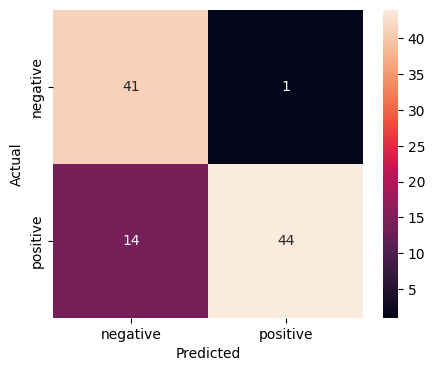

In [24]:
# Confusion matrix
y_values = twitter_data_model['target'].head(n_records)
conf_matrix = confusion_matrix(y_values, preds_label)
print('Matriz de Confusión:')
print(conf_matrix)
plot_cm(conf_matrix)

### Classification report

In [25]:
# Classification report
class_report = classification_report(y_values, preds_label)
print('Reporte de Clasificación:')
print(class_report);

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.75      0.98      0.85        42
           1       0.98      0.76      0.85        58

    accuracy                           0.85       100
   macro avg       0.86      0.87      0.85       100
weighted avg       0.88      0.85      0.85       100

